# TS Lab 2

### Imports + Generate the time series: 

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(7)

n = 120                      # 120 months = 10 years
t = np.arange(n)

trend = 0.05 * t
seasonality = 2.0 * np.sin(2 * np.pi * t / 12)   # yearly seasonality (period 12)
noise = np.random.normal(0, 0.8, size=n)

y = 10 + trend + seasonality + noise

ts = pd.Series(
    y,
    index=pd.period_range("2015-01", periods=n, freq="M").to_timestamp()
)

ts.head()

2015-01-01    11.352421
2015-02-01    10.677250
2015-03-01    11.858307
2015-04-01    12.476013
2015-05-01    11.300912
Freq: MS, dtype: float64

### Basic setup for forecasting horizon

In [63]:
future_steps = 24  # predict next 24 months
t_future = np.arange(n + future_steps)

X = t.reshape(-1, 1)
X_future = t_future.reshape(-1, 1)

# Future datetime index for plotting (monthly)
future_index = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=future_steps, freq="MS")
full_index = ts.index.append(future_index)

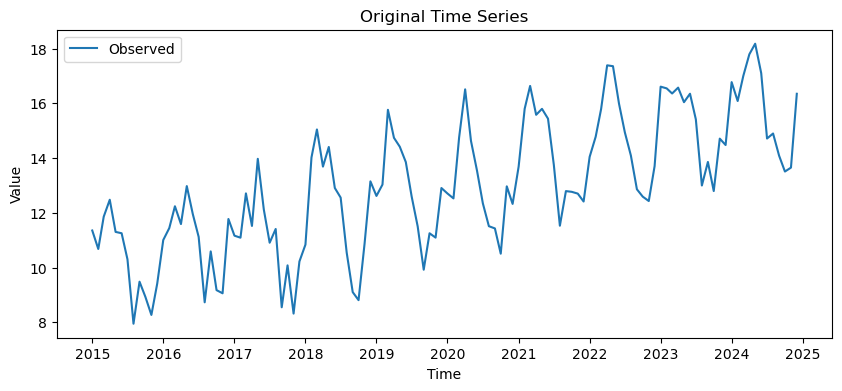

In [64]:
plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, label="Observed")
plt.title("Original Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

### Linear Regression (trend only)

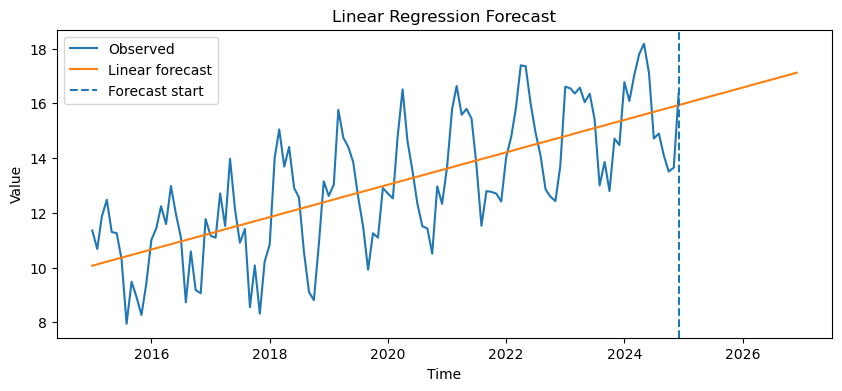

In [65]:
lin_model = LinearRegression()
lin_model.fit(X, y)
y_lin_pred = lin_model.predict(X_future)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_lin_pred, label="Linear forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title("Linear Regression Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- What happens if the trend slope in the data becomes steeper?

- In which situations would a linear regression model be appropriate for time series forecasting?

### Polynomial Regression

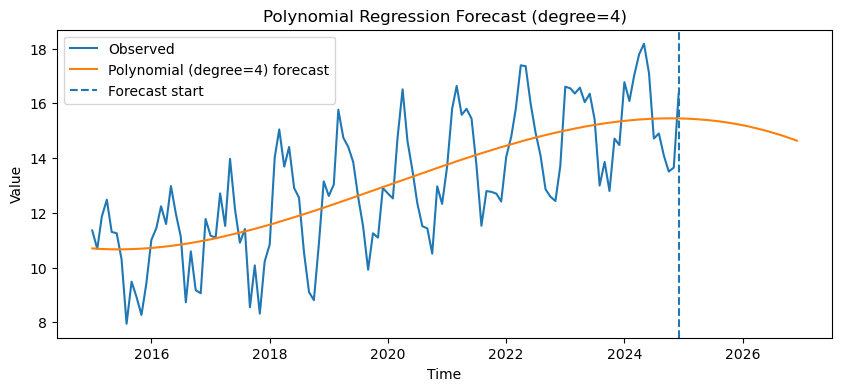

In [66]:
degree = 4

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)
X_future_poly = poly.transform(X_future)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_future_poly)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_poly_pred, label=f"Polynomial (degree={degree}) forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title(f"Polynomial Regression Forecast (degree={degree})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- Change the degree of the polynomial (for example, 2, 3, 5). How does the curve change?

- What happens if the polynomial degree becomes very large?

- Can polynomial regression capture seasonal patterns in this dataset?

- What is the risk of using very high-degree polynomials?

### Logarithmic Regression

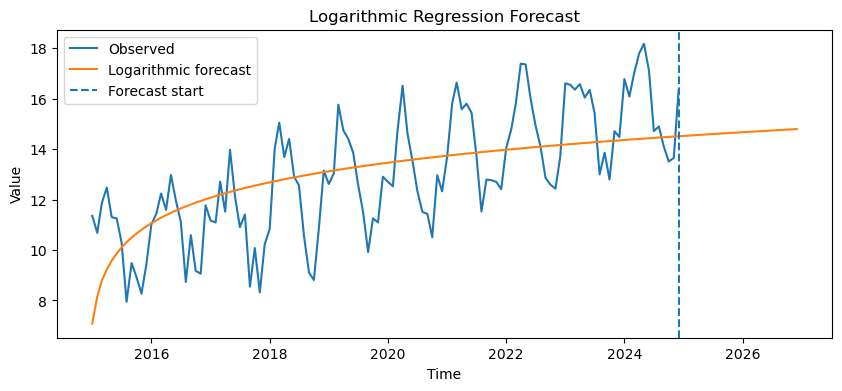

In [67]:
X_log = np.log(t + 1).reshape(-1, 1)
X_future_log = np.log(t_future + 1).reshape(-1, 1)

log_model = LinearRegression()
log_model.fit(X_log, y)
y_log_pred = log_model.predict(X_future_log)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_log_pred, label="Logarithmic forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title("Logarithmic Regression Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- Why do we use log(t + 1) instead of log(t)?

- Does the logarithmic model capture the seasonal fluctuations in the data?

### Exponential Regression

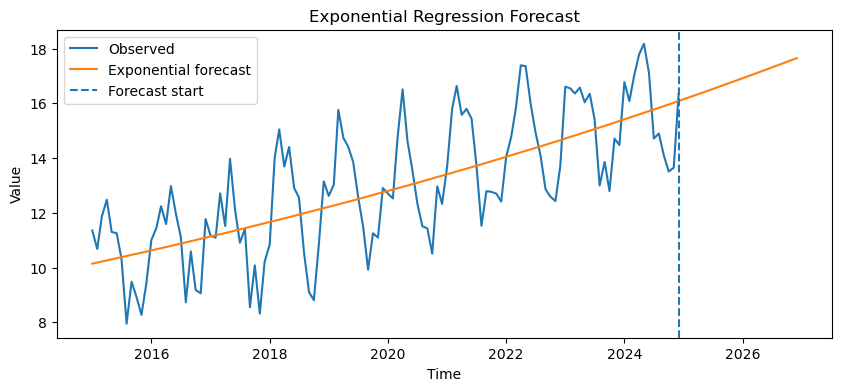

In [68]:
# safety: ensure positivity for log
shift = 0.0
if np.any(y <= 0):
    shift = abs(y.min()) + 1e-6

log_y = np.log(y + shift)

exp_model = LinearRegression()
exp_model.fit(X, log_y)
y_exp_pred = np.exp(exp_model.predict(X_future)) - shift

plt.figure(figsize=(10, 4))
plt.plot(ts.index, y, label="Observed")
plt.plot(full_index, y_exp_pred, label="Exponential forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title("Exponential Regression Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- What type of growth does an exponential model represent?

- Why do we apply a log transformation when fitting the exponential model?

### ARIMA

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


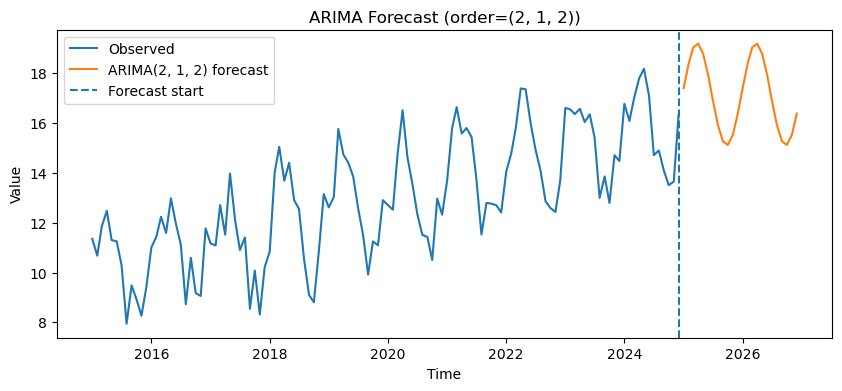

In [69]:
order = (2, 1, 2)

arima_model = ARIMA(ts, order=order)
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=future_steps)

plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, label="Observed")
plt.plot(arima_forecast.index, arima_forecast.values, label=f"ARIMA{order} forecast")
plt.axvline(ts.index[-1], linestyle="--", label="Forecast start")
plt.title(f"ARIMA Forecast (order={order})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

- How is ARIMA different from regression models used earlier?

- What does ARIMA use to make predictions?

- What do the parameters (p, d, q) represent?

### Evaluation Metrics:
Import metrics libraries.

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

### Predictions on training data: 
We compute predictions for the observed period only (first n points).

In [71]:
# Linear
y_lin_train = lin_model.predict(X)

# Polynomial
y_poly_train = poly_model.predict(X_poly)

# Logarithmic
y_log_train = log_model.predict(X_log)

# Exponential
y_exp_train = np.exp(exp_model.predict(X)) - shift

# ARIMA fitted values
y_arima_train = arima_fit.fittedvalues

### Define evaluation metrics

In [72]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, mse, rmse, mape

### Compute metrics for each model

In [73]:
results = {}

results["Linear"] = evaluate(y, y_lin_train)
results["Polynomial"] = evaluate(y, y_poly_train)
results["Logarithmic"] = evaluate(y, y_log_train)
results["Exponential"] = evaluate(y, y_exp_train)
results["ARIMA"] = evaluate(y[1:], y_arima_train[1:])  # ARIMA first value often NaN

metrics_df = pd.DataFrame(results, 
                          index=["MAE", "MSE", "RMSE", "MAPE (%)"]).T

metrics_df

,MAE,MSE,RMSE,MAPE (%)
Linear,1.444105,2.869234,1.693881,11.647208
Polynomial,1.426736,2.818985,1.678983,11.476666
Logarithmic,1.591041,3.692583,1.921609,13.049097
Exponential,1.444235,2.888816,1.699652,11.532150
ARIMA,0.964010,1.368336,1.169759,7.853366


- What is the difference between MSE and RMSE?

- Why does RMSE penalize large errors more strongly than MAE?

- Which model achieved the lowest forecasting error?

- Do different metrics always rank models the same way?